# Agentic RAG with LangGraph

## You've Measured the Pipeline... Now What?

In **Tutorial 1A**, you learned how to chunk documents.  
In **Tutorial 1B**, you learned how to optimize and route queries.  
In **Tutorial 2A** and **2B**, you learned retrieval and orchestration.  
In **Tutorial 3**, you learned post-retrieval context preparation.  
In **Tutorial 4**, you learned how to evaluate each pipeline stage.

Now comes the production pattern: **Wrapping retrieval in an agent that decides when to search.**

---

## The Journey So Far

```
Tutorial 1A: Chunking ✅
    ↓
Tutorial 1B: Query Optimization ✅
    ↓
Tutorial 2A: Core Retrieval Methods ✅
    ↓
Tutorial 2B: Smart Orchestration ✅
    ↓
Tutorial 3: Post-Retrieval ✅
    ↓
Tutorial 4: Evaluation ✅
    ↓
Tutorial 5: Agentic RAG ← You are here
```

**You've built and measured a linear pipeline. Now let's put an LLM in the loop.**

---

## The Challenge

Production RAG is rarely a single retrieve → generate path:

- Some queries are greetings - **no retrieval needed**
- Some need a **rewritten search query** before hitting the index
- The same retrieval stack must sit behind a **tool** the agent can call (or skip)

**The question:** How do the techniques from Tutorials 1-4 map to an agentic workflow?

---

## What You'll Learn

We'll build a minimal **LangGraph ReAct agent** with one retrieval tool:

**The Pattern:**
1. **Prompt-based routing** - When to search vs answer directly (replaces `semantic_layer` for this demo)
2. **Prompt-based query clarification** - Rewrite before searching (replaces `expand_query` for this demo)
3. **Retrieval tool** - Vector RAG over workshop PDFs (`retrieve_workshop_docs`)
4. **Lightweight tool eval** - Did the agent pick the right capability? (full metrics stay in Tutorial 4)

**Intentionally skipped in this demo** (add inside the tool when needed):
- Reranking (Tutorial 2A)
- Context preparation (Tutorial 3)

---

## Tutorial Structure

```
Part 1: Setup & Retrieval Tool
    ↓
Part 2: LangGraph Agent + System Prompt
    ↓
Part 3: Run the Agent (Try It)
    ↓
Part 4: Lightweight Tool-Selection Check
    ↓
Conclusion & Production Next Steps
```

**Our approach:** Keep the agent simple - one RAG tool, prompt handles routing. Measure tool choice here; measure retrieval quality in Tutorial 4.

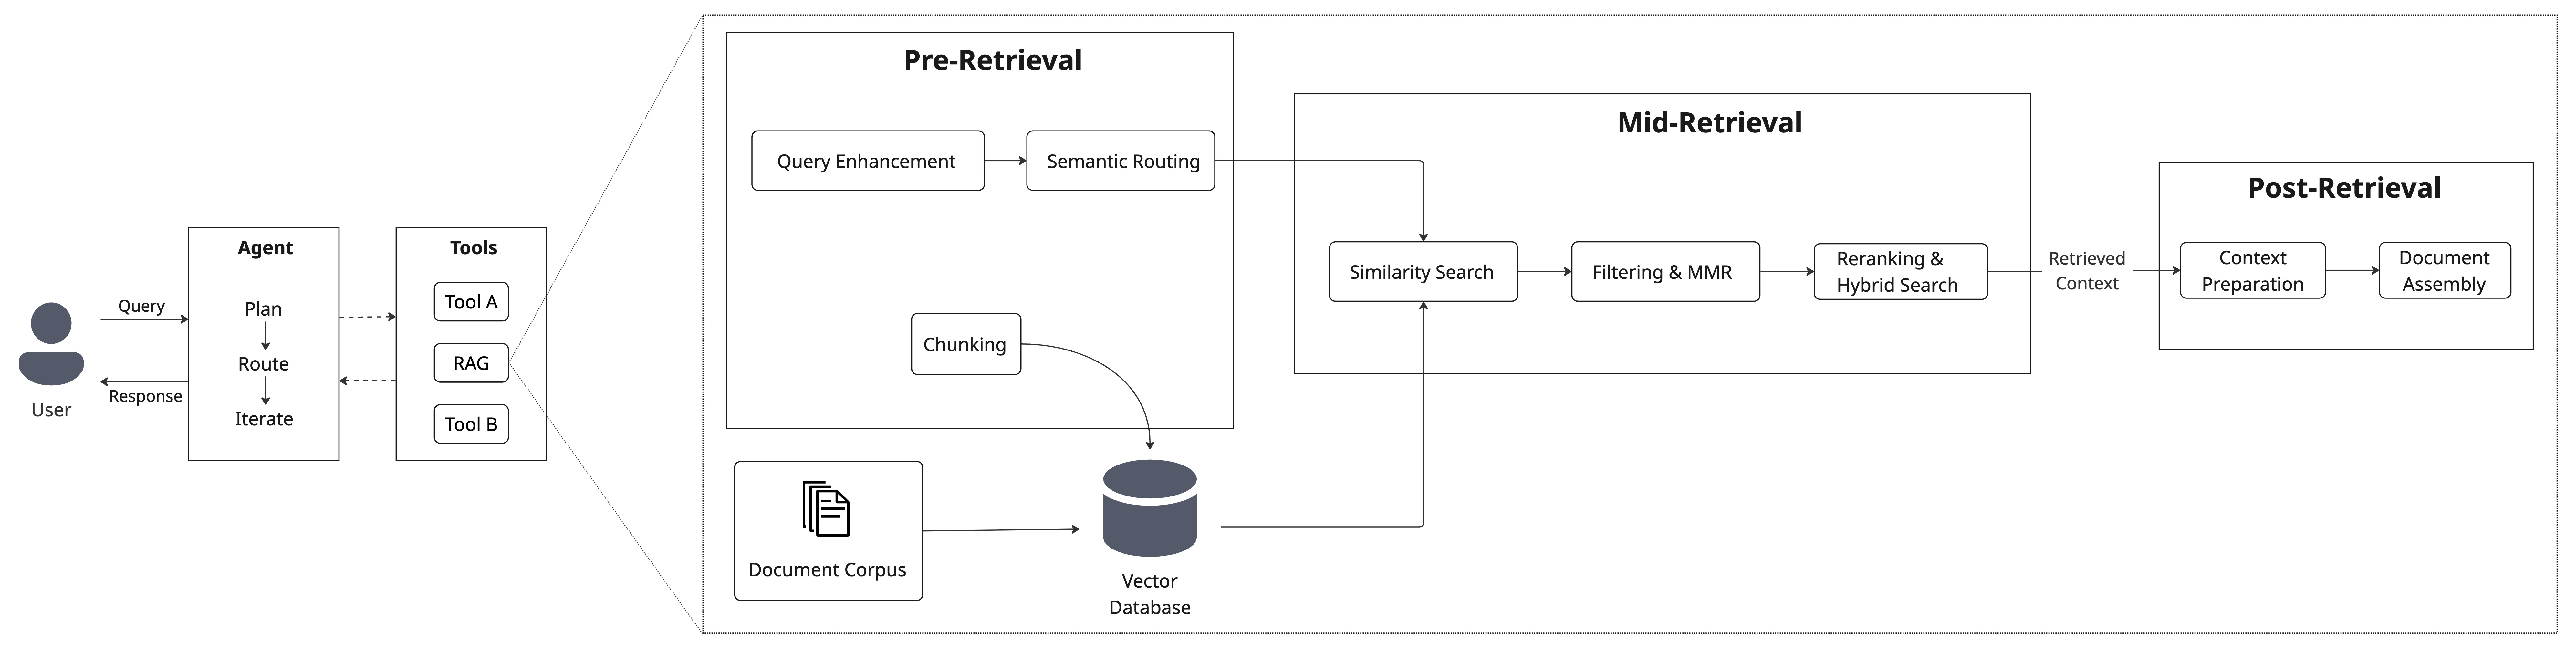

All agent and tool code lives **in this notebook**.

Let's agentize! 🚀


## Setup

In [1]:
import json
import warnings
from typing import Any, Dict, List, Union

from langchain_core.documents import Document
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent

from retrieval_playground.utils import config
from retrieval_playground.utils import constants
from retrieval_playground.utils.model_manager import model_manager
from retrieval_playground.src.baseline_rag import RAG
from retrieval_playground.src.pre_retrieval.chunking_manager import ChunkingStrategy
from retrieval_playground.src.evaluation.tool_metrics import ToolEvaluator, ToolTrace

import logging
logging.getLogger().setLevel(logging.WARNING)
warnings.filterwarnings("ignore")

llm = model_manager.get_llm()
DEFAULT_COLLECTION = ChunkingStrategy.RECURSIVE_CHARACTER.value
RETRIEVE_K = 2
rag = RAG(strategy=ChunkingStrategy.RECURSIVE_CHARACTER)

AVAILABLE_COLLECTIONS = constants.SUPPORTED_COLLECTIONS
pipeline_trace: List[Dict[str, Any]] = []


def _answer_text(content: Union[str, list]) -> str:
    """Normalize Gemini / LangChain message content to plain text."""
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts = []
        for block in content:
            if isinstance(block, dict) and block.get("text"):
                parts.append(block["text"])
            elif isinstance(block, str):
                parts.append(block)
        return "".join(parts)
    return str(content)


def _format_docs(docs: List[Document]) -> str:
    if not docs:
        return "No documents found."
    blocks = []
    for doc in docs:
        source = doc.metadata.get("source", "unknown")
        blocks.append(f"[{source}]\n{doc.page_content[:600]}")
    return "\n\n---\n\n".join(blocks)




onnxruntime cpuid_info warning: Unknown CPU vendor. cpuinfo_vendor value: 0
2026-07-08 11:13:17 - numexpr.utils - INFO - utils.py:164 - _init_num_threads() - NumExpr defaulting to 2 threads.


2026-07-08 11:13:19.301 INFO model_manager - _initialize_models: 🔄 ModelManager: Initializing shared AI models...


2026-07-08 11:13:19 - rp_logger - INFO - model_manager.py:65 - _initialize_models() - 🔄 ModelManager: Initializing shared AI models...


2026-07-08 11:13:19.319 INFO model_manager - _initialize_models: ✅ ModelManager: Shared AI models initialized successfully


2026-07-08 11:13:19 - rp_logger - INFO - model_manager.py:81 - _initialize_models() - ✅ ModelManager: Shared AI models initialized successfully


2026-07-08 11:13:19.327 INFO baseline_rag - __init__: BaselineRAG pipeline initialized


2026-07-08 11:13:19 - rp_logger - INFO - baseline_rag.py:55 - __init__() - BaselineRAG pipeline initialized


## 1. Retrieval tool (vector RAG)

One tool wraps baseline retrieval from Tutorial 2:

1. **Embed the query** and search Qdrant
2. **Return top-k chunks** to the agent

Query routing and abbreviation expansion live in the **system prompt**, not in separate tools.

> **Optional extensions:** Add Tutorial 2A's `Reranker` or Tutorial 3's grading inside this tool when you need better ordering or cleaner context — then compare scores in Tutorial 4.


In [2]:
@tool
def retrieve_workshop_docs(
    question: str,
    collection: str = DEFAULT_COLLECTION,
) -> str:
    """
    Retrieve workshop PDF chunks via vector search (Qdrant).

    Use for technical questions about the indexed workshop papers.
    Call once per user question; answer from the returned text.

    Args:
        question: Clear search query with abbreviations already expanded
            (e.g. 'tensor processing unit', not 'TPU').
        collection: Qdrant collection (chunking strategy). **Leave default** for
            normal workshop questions — all workshop PDFs use the default index.

            Valid values only:
              - recursive_character (default)
              - parent_child
              - contextual
              - docling
              - hybrid

            Do NOT use invented names like 'workshop_papers' or 'workshop'.
            Only set `collection` if the user explicitly names a chunking strategy.

    Returns:
        Chunk text with source filenames, or a no-results message.
    """
    if collection not in AVAILABLE_COLLECTIONS:
        pipeline_trace.append({
            "step": "collection_fallback",
            "invalid": collection,
            "used": DEFAULT_COLLECTION,
        })
        collection = DEFAULT_COLLECTION

    pipeline_trace.append({"tool": "retrieve_workshop_docs", "collection": collection})

    pairs = rag.retrieve_context(question, k=RETRIEVE_K, collection_name=collection)
    docs = [doc for doc, _ in pairs]
    pipeline_trace.append({"step": "vector_search", "count": len(docs)})
    return _format_docs(docs)


tools = [retrieve_workshop_docs]


## 2. LangGraph ReAct agent + system prompt

The prompt is the decision layer: when to search, how to rewrite the query, and when to answer without the tool.


In [3]:
AGENT_PROMPT = """You are a helpful workshop assistant for ML and RAG papers indexed in Qdrant.

## Routing
- Greetings, thanks, and meta questions ("what can you do?"): answer directly. Do NOT call any tool.
- Technical questions about workshop papers: call `retrieve_workshop_docs` exactly once, then answer from its output.

## Before searching
Rewrite the user's question into a clear search query before calling the tool.
- Spell out abbreviations (ML → machine learning, TPU → tensor processing unit).
- Pass only `question`. Do NOT pass `collection` unless the user explicitly names a chunking strategy.

## Responses
- Base technical answers on retrieved documents.
- Cite source filenames when available.
- If no documents are found, say you could not find evidence in the workshop set.
"""

agent = create_react_agent(llm, tools, prompt=AGENT_PROMPT)


## 3. Run the agent

No `semantic_layer()` pre-hook — routing lives in the prompt (compare with Tutorial 1B's deterministic router).


In [4]:
def _tool_names_from_messages(messages) -> List[str]:
    names = []
    for msg in messages:
        if isinstance(msg, AIMessage) and msg.tool_calls:
            for call in msg.tool_calls:
                names.append(call["name"])
    return names


def run_agent_query(query: str, verbose: bool = True) -> Dict[str, Any]:
    """Invoke the agent; routing and query rewrite are handled by the system prompt."""
    global pipeline_trace
    pipeline_trace = []

    result = agent.invoke({"messages": [HumanMessage(content=query)]})
    messages = result["messages"]
    tools_used = _tool_names_from_messages(messages)
    answer = _answer_text(messages[-1].content)

    if verbose:
        print(f"Tools used: {tools_used or ['none (direct answer)']}")
        if pipeline_trace:
            print("Pipeline trace:", pipeline_trace)
        print()

    return {
        "query": query,
        "tools_used": tools_used,
        "answer": answer,
        "messages": messages,
        "pipeline_trace": pipeline_trace,
    }


### Try it

Run the smoke test cell above first, then the examples below.


In [5]:
# Greeting — prompt should route to direct answer (no tool)
greeting_run = run_agent_query("Hi! What can you help me with?")
print("Answer:", greeting_run["answer"][:300])


Tools used: ['none (direct answer)']

Answer: I can help you with technical questions about the machine learning and RAG workshop papers that have been indexed in our system.

Feel free to ask me anything about the content of those papers


In [6]:
# Technical question — agent calls retrieve_workshop_docs
rag_run = run_agent_query("what's a TPU actually for in modern ML infra?")
print("Answer:")
print(rag_run["answer"])

Tools used: ['retrieve_workshop_docs']
Pipeline trace: [{'tool': 'retrieve_workshop_docs', 'collection': 'recursive_character'}, {'step': 'vector_search', 'count': 2}]

Answer:
Based on the documents from the workshop, Tensor Processing Units (TPUs) are specialized processors designed by Google to accelerate machine learning workloads.

Their architecture is particularly effective for the repetitive tensor operations common in large machine learning models, such as those used for natural language processing and computer vision. This specialization makes them faster and more efficient for these specific tasks compared to more general-purpose processors like CPUs or GPUs.

Google has also developed Edge TPUs, which are designed to run machine learning models on devices at the edge of the network, like in IoT or mobile applications.

While TPUs are highly efficient, they sometimes operate at a lower precision than GPUs. However, for many machine learning models, this doesn't lead to a sig

## 4. Lightweight tool check (not full Tutorial 4 eval)

[Tutorial 4](4_Evaluation.ipynb) runs the **full metric stack** — Hit@k, RAGAS, baseline vs post-retrieval, etc.

Here we only check **one agent-specific signal**: did the model pick the right capability?

| Check | Greeting | Technical question |
|-------|----------|-------------------|
| Expected | No tool | `retrieve_workshop_docs` |

We reuse the **Try it** runs above — no extra LLM calls. A miss usually means tighten the prompt or add deterministic routing (Tutorial 1B), not broken retrieval.


In [7]:
def _actual_tool(tools_used: List[str]) -> str:
    return tools_used[0] if tools_used else "none"


tool_traces = [
    ToolTrace(
        query="Hi! What can you help me with?",
        expected_tool="none",
        actual_tool=_actual_tool(greeting_run["tools_used"]),
    ),
    ToolTrace(
        query="what's a TPU actually for in modern ML infra?",
        expected_tool="retrieve_workshop_docs",
        actual_tool=_actual_tool(rag_run["tools_used"]),
    ),
]
for t in tool_traces:
    t.success = t.actual_tool == t.expected_tool

tool_eval = ToolEvaluator().evaluate(tool_traces)
print("Tool selection (2 demo queries):", round(tool_eval.scores["tool_selection_accuracy"], 2))
for row in tool_eval.details["tool_selection_accuracy"]:
    mark = "✅" if row["match"] else "❌"
    print(f"  {mark} expected={row['expected']} actual={row['actual']}")


Tool selection (2 demo queries): 1.0
  ✅ expected=none actual=none
  ✅ expected=retrieve_workshop_docs actual=retrieve_workshop_docs


## Conclusion

| Layer | Tutorial 1–4 | This notebook |
|-------|--------------|---------------|
| Pre-retrieval | `expand_query`, `semantic_layer` | System prompt |
| Retrieval | `RAG.retrieve_context` | `retrieve_workshop_docs` |
| Reranking | `Reranker` | Skipped — add inside tool when needed (Tutorial 2A) |
| Post-retrieval | Grading / compression | Skipped — add when needed (Tutorial 3) |
| Full eval | RAGAS + classical metrics | **Tutorial 4** — not repeated here |
| Agent eval | — | Tool selection only (2 demo queries) |

**Production next steps:** optional `Reranker` + `ContextPreparer` inside the tool, multiple collections, LangSmith logging.
